# 072 — Fragility dataset for the crossed regression models

Builds the one-row-per-`(site, structure)` table the statistical models in nb `073` are fitted
to, and draws the crossing between the site factor and the structure factor.

Each row carries, for all five analysis arms

| arm | module name | what it is |
|---|---|---|
| **MSA-FX** | `msa_femap695` | MSA on the fixed FEMA P695 record set, fitted per design group |
| **IDA-FX** | `ida_femap695` | IDA on the fixed FEMA P695 record set, lower bound of the collapse bracket, fitted per design group |
| **IDA-FX (ub)** | `ida_femap695_ub` | the same IDA, upper bound of the collapse bracket |
| **IDA-FX (avg)** | `ida_femap695_avg` | the same IDA, geometric mean of the collapse bracket |
| **MSA-SS** | `site_msa` | MSA on the site-specific (GCIM) records, fitted per site |

The three IDA rows are one analysis read three ways: an IDA resolves each record's capacity
only to a bracket between the highest intensity that ran and the lowest that collapsed, and
nb `070` §1.5 fits all three readings of it. nb `074` shows the lower bound - the capacity
every fragility in this chapter used up to that point - costs about 4.3% of median collapse
capacity against the MSA, while the bracket's geometric mean carries no such offset.

the median `theta`, the dispersion `beta`, their logs, the bootstrap variances on both scales,
the log-scale bias, and the bias-corrected values nb `070` writes — plus the two grouping factors:

* `site` — integer `0–59`, the case-study site;
* `structure_id` — integer `0–50`, the unique structural design (nb `051`: 25 designs at 3
  storeys, 26 at 5, 51 in total).

**Writes**

* `data_processed/10_fragility_curve_statistical_analysis/fragility_regression_dataset_AvgSA_03.csv`
* `data_processed/10_fragility_curve_statistical_analysis/crossed_structure_AvgSA_03.png`

## 1.0 Setup

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import phd_project.scripts.metaregression_analysis as mra
import phd_project.scripts.fragility_data_models as fm
from phd_project.config import config

cfg = config.load_config()

In [26]:
# Mirrors nb 070/073 - the replicate count, storey counts and IM the saved bootstrap
# frames were written with.
K_SAMPLES = 5000
N_STOREYS = [3, 5]
IM_TAG = "AvgSA_03"

# The arm registry, the dataset filename and the design-group labelling now live in
# fragility_data_models, so this notebook (the PRODUCER of the dataset) and nb 073
# (its consumer) cannot drift apart. ARMS is ordered, and that order sets the column
# order of the saved file.
ARMS = fm.ARMS

BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]
DESIGNS_CSV = cfg["proc_data"]["unique_structural_designs_csv"]

OUT_PTH = Path(BOOTSTRAP_PTH).parent          # .../10_fragility_curve_statistical_analysis
DATASET_CSV = fm.dataset_csv_path(BOOTSTRAP_PTH, IM_TAG)
PLOT_PNG = OUT_PTH / f"crossed_structure_{IM_TAG}.png"

print(f"bootstrap frames : {BOOTSTRAP_PTH}")
print(f"design groups    : {DESIGNS_CSV}")
print(f"dataset out      : {DATASET_CSV}")
for prefix, arm in ARMS.items():
    print(f"  {prefix:8s} -> {arm}")

bootstrap frames : C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\bootstrapping
design groups    : C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\unique_structural_designs.csv
dataset out      : C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\fragility_regression_dataset_AvgSA_03.csv
  msa_fx   -> msa_femap695
  ida_fx   -> ida_femap695
  ida_ub   -> ida_femap695_ub
  ida_avg  -> ida_femap695_avg
  msa_ss   -> site_msa


## 2.0 The structure factor

`unique_structural_designs.csv` (nb `051`) lists all 120 `(site, storeys)` pairs and the design
group each belongs to. Group ids restart at 0 for every storey count, so they are turned into a
single global factor by enumerating the sorted `(storeys, group_id)` keys: 3s designs take
`structure_id` 0–24 and 5s designs 25–50. The group is also carried through under its
canonical label, `design_group_id` (e.g. `group_3s_00`) — the folder name under
`wp1_design_groups/` and the index of the by-group bootstrap frames.

The enumeration is built from the **whole** table, not just the storey counts being exported, so
the ids do not shift when the 5s bootstrap is added later.

In [27]:
# fm.build_design_factors does the enumeration and asserts the full-study dimensions
# (51 designs, 120 rows, sites 0-59). The design_group_id convention it applies,
# f"group_{n}s_{gg:02d}", is the same one fm.FragilityData uses to map rows onto the
# by_group bootstrap frames - which is exactly why it should only be written once.
designs = fm.build_design_factors(DESIGNS_CSV)

print(designs.groupby("storeys")["structure_id"].agg(["min", "max", "nunique"]))
designs.head()

         min  max  nunique
storeys                   
3          0   24       25
5         25   50       26


,storeys,site,tag,group_id,fingerprint,representative_site,representative_tag,is_representative,n_sites_in_group,structure_id,design_group_id
0,3,0,3s_cbf_dc2_site0,0,26435b8268ee6bbf,0,3s_cbf_dc2_site0,True,8,0,group_3s_00
1,3,1,3s_cbf_dc2_site1,1,f401ac831c94d559,1,3s_cbf_dc2_site1,True,6,1,group_3s_01
2,3,2,3s_cbf_dc2_site2,1,f401ac831c94d559,1,3s_cbf_dc2_site1,False,6,1,group_3s_01
3,3,3,3s_cbf_dc2_site3,2,84d5e0674089226d,3,3s_cbf_dc2_site3,True,1,2,group_3s_02
4,3,4,3s_cbf_dc2_site4,0,26435b8268ee6bbf,0,3s_cbf_dc2_site0,False,8,0,group_3s_00


## 3.0 Assemble the per-arm columns

Everything is loaded through `phd_project/scripts/metaregression_analysis.py`, which owns the
filename convention, so the paths cannot drift from what nb `070` wrote.

**On the variances.** Both scales are computed straight from the 5000-replicate clouds with
`ddof=1`, matching the `y0.var(axis=1)` that nb `073` forms its effect-size variances with.
The saved `*_stats_*` CSVs report `variance` through `np.var`, i.e. `ddof=0`; the assertion
below checks the two agree after the `(N-1)/N` rescaling, and a second assertion checks
`var_log` against the independent `se_est` column of the bias frames. Together they guarantee
this table is consistent with the frames nb `070` saved.

**On the bias and corrected columns.** `log_{q}_bias` is the log-scale bias
`E[ln x*] - ln x_ref` (Efron & Tibshirani eq. 10.2) that nb `070` §2.2 measured - for the IDA
arms against the plug-in reference built in §2.1, for the MSA arms against their published
fit. `{q}_bc` and `log_{q}_bc` are the **bias-corrected estimates read straight from the
`*_estimates_*` file**, not recomputed here: nb `070` §2.4 writes them as
`x_bc = x_hat * exp(-b)`, applied to the published `x_hat`. Because §2.2 corrects `ln(theta)`
by zero, `theta_bc` is `theta` copied across and only `beta_bc` moves, by about +2%. The
assertions below tie the two files together rather than trusting them to agree.

The old `*_bias_corrected` columns are gone. They held the *residual* left after the
correction, which is zero by construction now that every arm subtracts its own bias - see
nb `070` §2.3, where the same column was dropped from the diagnostic grid.

**Whether to use them.** Carrying `beta_bc` is not the same as adopting it. Every arm's
`|bias|/se` comes out between 0.08 and 0.15, well inside the 0.25 band where a correction
costs more in variance than it removes in bias, so the models in nb `073` are fitted to
`log_beta`; `log_beta_bc` is the audit trail showing the check was made.

In [28]:
def arm_columns(prefix: str, arm: str, n_storeys: int) -> dict[str, pd.Series] | None:
    """Build one arm's column block for one storey count, and CHECK it.

    fm.arm_column_block does the mechanical half - load, log, var(ddof=1), lay the
    columns out under the canonical names - and hands back its intermediates. The
    assertions below stay here, in the notebook, on purpose: they tie together files
    written by different cells of nb 070, and they are the actual purpose of this
    notebook. They are a gate on the dataset, not a library routine, and nb 073 should
    not pay for them on every model fit.

    Returns ``None`` when the saved replicate frames for this storey count are missing.
    """
    block = fm.arm_column_block(BOOTSTRAP_PTH, prefix, arm, n_storeys, IM_TAG,
                                k_samples=K_SAMPLES)
    if block is None:
        print(f"  {arm:20s}: no saved bootstrap for {n_storeys}s")
        return None
    cols, parts = block
    ests = parts["ests"]

    for q in ("theta", "beta"):
        part = parts["quantities"][q]
        stat, bias_q = part["stat"], part["bias"]

        # the saved variance is np.var (ddof=0) - rescale before comparing
        n = stat["N_obs"]
        np.testing.assert_allclose(part["var_nat"] * (n - 1) / n, stat["variance"],
                                   rtol=1e-9)
        # se_est is the ddof=1 std of the log cloud, computed independently in nb 070
        np.testing.assert_allclose(part["var_log"], bias_q["se_est"] ** 2, rtol=1e-9)

        # The estimates file and the bias file are written by different cells of nb 070,
        # and nothing has tied them together until here. Section 2.4's convention, written
        # out explicitly there, is theta corrected by nothing and beta by its own bias.
        if q == "theta":
            pd.testing.assert_series_equal(ests["theta"], ests["theta_bc"],
                                           check_names=False)
        else:
            np.testing.assert_allclose(np.log(ests[q] / ests[f"{q}_bc"]), bias_q["bias"],
                                       rtol=1e-9)

    # theta and beta come out of the same fits, so their usable-replicate counts must agree
    pd.testing.assert_series_equal(parts["n_obs"]["theta"], parts["n_obs"]["beta"],
                                   check_names=False)
    return cols

In [29]:
def build_rows(n_storeys: int) -> pd.DataFrame | None:
    """One frame of arm columns for every site at this storey count, or None if unavailable."""
    print(f"{n_storeys}s:")
    blocks = {}
    for prefix, arm in ARMS.items():
        cols = arm_columns(prefix, arm, n_storeys)
        if cols is None:
            print(f"  -> skipping {n_storeys}s entirely")
            return None
        blocks.update(cols)
        print(f"  {arm:14s}: ok")

    df = pd.DataFrame(blocks)
    df.insert(0, "n_storeys", n_storeys)
    return df.reset_index()


frames = [f for f in (build_rows(n) for n in N_STOREYS) if f is not None]
if not frames:
    raise RuntimeError("no storey count has saved bootstrap frames - run nb 070 first")

rows = pd.concat(frames, ignore_index=True)
print(f"\n{len(rows)} rows x {rows.shape[1]} columns")
rows.head()

3s:
  msa_femap695  : ok
  ida_femap695  : ok
  ida_femap695_ub: ok
  ida_femap695_avg: ok
  site_msa      : ok
5s:
  msa_femap695  : ok
  ida_femap695  : ok
  ida_femap695_ub: ok
  ida_femap695_avg: ok
  site_msa      : ok

120 rows x 77 columns


,site,n_storeys,msa_fx_theta,msa_fx_log_theta,msa_fx_theta_bc,msa_fx_log_theta_bc,msa_fx_var_theta,msa_fx_var_log_theta,msa_fx_log_theta_bias,msa_fx_beta,...,msa_ss_var_log_theta,msa_ss_log_theta_bias,msa_ss_beta,msa_ss_log_beta,msa_ss_beta_bc,msa_ss_log_beta_bc,msa_ss_var_beta,msa_ss_var_log_beta,msa_ss_log_beta_bias,msa_ss_n_obs
0,0,3,0.411665,-0.887545,0.411665,-0.887545,0.000324,0.001906,-0.000105,0.206602,...,0.001009,-0.000426,0.273254,-1.297354,0.273978,-1.294709,0.002119,0.026596,-0.002645,5000
1,1,3,0.392731,-0.934629,0.392731,-0.934629,0.000212,0.001356,0.000818,0.159779,...,0.000718,0.000242,0.225325,-1.490210,0.227760,-1.479461,0.001150,0.022018,-0.010749,5000
2,2,3,0.392731,-0.934629,0.392731,-0.934629,0.000212,0.001356,0.000818,0.159779,...,0.000718,0.000269,0.229964,-1.469833,0.232484,-1.458936,0.001433,0.025959,-0.010897,5000
3,3,3,0.402997,-0.908826,0.402997,-0.908826,0.000246,0.001505,0.000184,0.181266,...,0.000926,0.000607,0.244984,-1.406560,0.247998,-1.394337,0.001191,0.019617,-0.012224,5000
4,4,3,0.411665,-0.887545,0.411665,-0.887545,0.000324,0.001906,-0.000105,0.206602,...,0.001784,0.003560,0.351250,-1.046256,0.349465,-1.051352,0.005597,0.038979,0.005095,5000


## 4.0 Attach the factors and order the columns

In [30]:
FACTORS = list(fm.DATASET_FACTORS)

data = rows.merge(
    designs[["site", "storeys", "structure_id", "tag", "design_group_id",
             "n_sites_in_group", "is_representative"]],
    left_on=["site", "n_storeys"], right_on=["site", "storeys"],
    how="left", validate="one_to_one",
).drop(columns="storeys")

# fm.order_dataset_columns puts the factors first and then each arm's block in ARMS
# order, and refuses to proceed if one arm prefix shadows another (which would match
# the same column twice and duplicate it).
data = (fm.order_dataset_columns(data)
        .sort_values(["n_storeys", "site"])
        .reset_index(drop=True))

assert data[FACTORS].notna().all().all(), "a factor column has missing values"
assert not data.duplicated(["site", "n_storeys"]).any()
assert data["structure_id"].between(0, 50).all()
for n in data["n_storeys"].unique():
    assert sorted(data.loc[data["n_storeys"] == n, "site"]) == list(range(60))

data["structure_id"] = data["structure_id"].astype(int)
data["site"] = data["site"].astype(int)

print(f"{data.shape[0]} rows x {data.shape[1]} columns")
data.head()

120 rows x 82 columns


,site,n_storeys,structure_id,tag,design_group_id,n_sites_in_group,is_representative,msa_fx_theta,msa_fx_log_theta,msa_fx_theta_bc,...,msa_ss_var_log_theta,msa_ss_log_theta_bias,msa_ss_beta,msa_ss_log_beta,msa_ss_beta_bc,msa_ss_log_beta_bc,msa_ss_var_beta,msa_ss_var_log_beta,msa_ss_log_beta_bias,msa_ss_n_obs
0,0,3,0,3s_cbf_dc2_site0,group_3s_00,8,True,0.411665,-0.887545,0.411665,...,0.001009,-0.000426,0.273254,-1.297354,0.273978,-1.294709,0.002119,0.026596,-0.002645,5000
1,1,3,1,3s_cbf_dc2_site1,group_3s_01,6,True,0.392731,-0.934629,0.392731,...,0.000718,0.000242,0.225325,-1.490210,0.227760,-1.479461,0.001150,0.022018,-0.010749,5000
2,2,3,1,3s_cbf_dc2_site2,group_3s_01,6,False,0.392731,-0.934629,0.392731,...,0.000718,0.000269,0.229964,-1.469833,0.232484,-1.458936,0.001433,0.025959,-0.010897,5000
3,3,3,2,3s_cbf_dc2_site3,group_3s_02,1,True,0.402997,-0.908826,0.402997,...,0.000926,0.000607,0.244984,-1.406560,0.247998,-1.394337,0.001191,0.019617,-0.012224,5000
4,4,3,0,3s_cbf_dc2_site4,group_3s_00,8,False,0.411665,-0.887545,0.411665,...,0.001784,0.003560,0.351250,-1.046256,0.349465,-1.051352,0.005597,0.038979,0.005095,5000


## 6.0 The crossed structure

Sites on the left, unique structural designs on the right, one line per row of the dataset.
Both columns run in id order, top to bottom: sites 0–59 on the left, structures 0–50 on the
right. The crossings that result are real — the sites sharing a design are scattered across the
site numbering, not contiguous in it.

wrote C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\crossed_structure_AvgSA_03.png


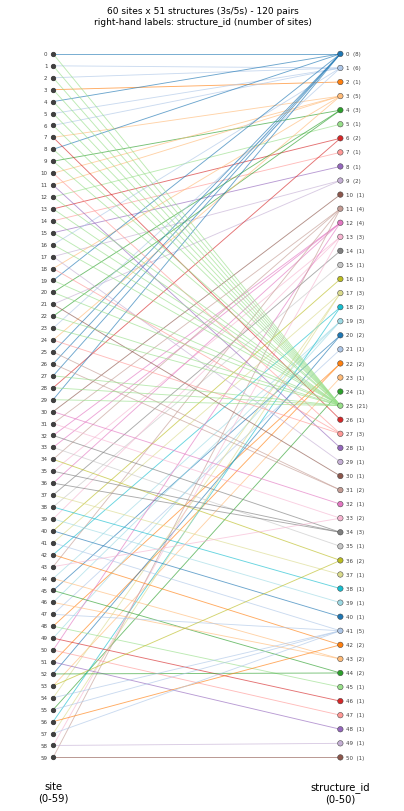

In [31]:
def plot_crossed_structure(df: pd.DataFrame, ax=None):
    """Bipartite site <-> structure diagram, one line per (site, structure) row.

    Both columns are in id order top to bottom, so a site or a design can be read straight
    off the axis.
    """
    sites = sorted(df["site"].unique())
    order = sorted(df["structure_id"].unique())

    site_y = {s: i for i, s in enumerate(sites)}
    span = np.linspace(0, len(sites) - 1, len(order)) if len(order) > 1 else [0.0]
    struct_y = dict(zip(order, span))

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 0.20 * len(sites) + 1.6))

    cmap = plt.get_cmap("tab20")
    colour = {s: cmap(i % 20) for i, s in enumerate(order)}

    for _, r in df.iterrows():
        ax.plot([0, 1], [site_y[r["site"]], struct_y[r["structure_id"]]],
                color=colour[r["structure_id"]], lw=0.9, alpha=0.65, zorder=1)

    ax.scatter([0] * len(sites), [site_y[s] for s in sites],
               s=18, color="0.25", zorder=3)
    ax.scatter([1] * len(order), [struct_y[s] for s in order],
               s=30, color=[colour[s] for s in order], edgecolor="0.25",
               linewidth=0.5, zorder=3)

    for s in sites:
        ax.text(-0.02, site_y[s], str(s), ha="right", va="center", fontsize=5.5,
                color="0.25")
    for s in order:
        n = int((df["structure_id"] == s).sum())
        ax.text(1.02, struct_y[s], f"{s}  ({n})", ha="left", va="center", fontsize=5.5,
                color="0.25")

    ax.set_xlim(-0.16, 1.20)
    ax.set_ylim(-1.5, len(sites) + 0.5)
    ax.invert_yaxis()
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["site\n(0-59)", "structure_id\n(0-50)"])
    ax.tick_params(axis="x", length=0, pad=6)
    ax.set_yticks([])
    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_visible(False)

    storeys = "/".join(f"{n}s" for n in sorted(df["n_storeys"].unique()))
    ax.set_title(f"{df['site'].nunique()} sites x {df['structure_id'].nunique()} structures "
                 f"({storeys}) - {len(df)} pairs\n"
                 f"right-hand labels: structure_id (number of sites)", fontsize=9, pad=12)
    return ax


ax = plot_crossed_structure(data)
ax.figure.savefig(PLOT_PNG, dpi=200, bbox_inches="tight")
print(f"wrote {PLOT_PNG}")
plt.show()

Every site carries two edges - one to a 3-storey design and one to a 5-storey design in the
25-50 block - and the sets of sites sharing a 5s design are *not* the sets sharing a 3s
design. That is the crossing the model exploits: neither factor is nested inside the other,
so a site effect and a structure effect can be told apart.

What the figure already shows is the imbalance the model has to cope with: a handful of designs
carry six to eight sites while many carry one, so the structure random effect is estimated far
more precisely for some levels than others.

## 7.0 Using the dataset

`fragility_regression_dataset_AvgSA_03.csv` is the single input for nb `073`; the contrasts it
forms are just differences of the `*_log_theta` / `*_log_beta` columns, e.g. the A0 effect is
`msa_ss_log_theta - ida_fx_log_theta`.

One property to keep in mind when specifying the model: **four of the five arms are constant
within a structure group by construction.** They are fitted once per design group and fanned out
to the member sites by `mra.expand_groups_to_sites`, so `msa_fx_*`, `ida_fx_*`, `ida_ub_*` and
`ida_avg_*` carry no within-structure variation at all. Only `msa_ss_*` varies site by site — it is the one arm whose
records are site-specific, and separating that variation from the structure effect is the whole
point of the crossed model.

The within-row bootstrap variances (`*_var_log_*`) are sampling variances of each fit and belong
in the model as known measurement error; they are **not** interchangeable with the variance of
a difference between two arms --> this needs to be obtained directly from the difference of the bootstrap replicates

## 8.0 Regression covariates

The A3+ meta-regressions explain the A1 contrast $y^{(1)}_i = a_i - b_{g[i]} = \ln\theta_{SS,i} - \ln\theta_{FX,g[i]}$,
i.e. how far the site-specific (GCIM) record set moves the collapse median away from the fixed FEMA P695 set.
The covariates are fixed in `admin/regression_covariates.md`; this section builds them. It supersedes the
exploratory nb `078`.

**Site / ground-motion covariates**, all *site minus FEMA set*, in log space, so that 0 means "this site's ground
motion looks like the FEMA set":

| column | site side (GCIM target, given AvgSA[0,3] = level) | FEMA side (22 records) | varies with |
|---|---|---|---|
| `d_ln_saratio_mean_rtpR` | $E[\ln \mathrm{SaRatio}(T_1)]$ | mean over records of $\ln \mathrm{SaRatio}(T_1)$ | row |
| `d_ln_saratio_sigma_rtpR` | $SD[\ln \mathrm{SaRatio}(T_1)]$ | SD over records | row |
| `d_ln_ds595_mean_rtpR` | $E[\ln D_{s5-95}]$ | mean over records of $\ln D_{s5-95}$ | site |
| `d_ln_ds595_sigma_rtpR` | $SD[\ln D_{s5-95}]$ | SD over records | site |

**Structure covariates**

| column | definition | varies with |
|---|---|---|
| `ln_T1` | modal first-mode period of the OpenSees model | design |
| `ln_overstrength` | $\ln\Omega$, $\Omega = V_{max}/V_{design}$ (pushover) | design |
| `ln_cs_over_avgsa_rtpR` | $\ln(C_s / \mathrm{AvgSA}[0,3](R))$ | row (design × site) |
| `ln_ductility` | $\ln\mu_T$, $\mu_T = \delta_u/\delta_{y,eff}$ (pushover) | design |

`R` runs over the four **hazard-fixed** conditioning levels, AvgSA[0,3] at 475, 2500, 5000 and 10 000 yr. The
level is fixed by hazard alone, never by the fragility: a level chosen from $\theta_{SS}$ would put the response
into the predictor. Which $R$ is primary is decided later; they are near-collinear, so only one enters a model.

SaRatio (Eads et al. 2016; Zhong et al. 2022, *Earthquake Spectra* 38(3), Eq. 2, p. 1897, page approximate):

$$\mathrm{SaRatio}(T_1) = \frac{\mathrm{SA}(T_1)}{\left[\prod_{i=1}^{n}\mathrm{SA}(T_i)\right]^{1/n}},\qquad
T_i \in [0.2T_1 : 0.01\,\mathrm{s} : 3T_1],$$

so $\ln\mathrm{SaRatio} = \ln\mathrm{SA}(T_1) - \frac1n\sum_i \ln\mathrm{SA}(T_i)$: how tall the spectrum is at $T_1$
compared with its average height over the band the structure moves through as it softens.

**Outputs.** The difference covariates are appended to `fragility_regression_dataset_AvgSA_03.csv` (section 9).
The separate site and FEMA values behind every difference go to
`fragility_regression_covariate_components_AvgSA_03.csv`, one row per (site, structure).

**What runs elsewhere.** The disaggregation at the four return periods is an OpenQuake job (section 8.3,
`RUN_OQ`), and the pushover / modal results come from nb 055 → nb 056. Until those products exist the dependent
columns are NaN (disaggregation) or flagged dummies (pushover), and the notebook says so.

In [32]:
from copy import deepcopy
from string import Template

from openquake.hazardlib.imt import SA, AvgSA
from pickagm.distributions import _conditional_im_distributions
from pickagm.corrmodels import conditional_correlation_matrix
from standes.groundmotion import load_ground_motion_from_json, response_spectrum

from phd_project.scripts import oq_runner, oqhelpers
from phd_project.scripts.cache_utils import (
    fingerprint, load_or_compute, manifest_matches, write_manifest)
from phd_project.scripts.msa_ida_hypothesis_testing import site_hazard_at_return_periods
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    calculate_gcim_distributions_for_sites, create_corr_model_map, _initialise_ctx_builder)
from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA03_gm_selection import (
    setup_AvgSA03_gcim_gm_selection, SELECTION_CONFIG)
import json
import pickle
import re

In [33]:
# -----------------------------------------------------------------------------
# COVARIATE PARAMETERS
# -----------------------------------------------------------------------------
IMT = "AvgSA"                      # key of the conditioning IM in hazard / disagg dicts
COND_IMT = AvgSA([0, 3])           # the conditioning IM object (GCIM, correlations)
N_SITES, N_ROWS, N_GROUPS = 60, 120, 51
TRUNCATION = 4                     # epsilon truncation of the hazard products

# Hazard-fixed conditioning levels [yr]. All four are carried; the primary one is
# chosen later (2500 yr is still well below most collapse medians).
RTPS = (475, 2500, 5000, 10000)

# SaRatio band (Zhong et al. 2022 Eq. 2, after Eads et al. 2016). Band periods are
# rounded to 3 decimals so they are identical to the labels the correlation model
# writes (f"SA({round(T, 3)})") - otherwise the GCIM lookup by label would fail.
SARATIO_TA, SARATIO_TB, SARATIO_DT = 0.2, 3.0, 0.01

# FEMA P695 spectrum grid [s]. It must cover 0.2 * min(T1) to 3 * max(T1) (checked
# in 8.1). The spectra are cached against these bounds: change them and the 22
# spectra are recomputed (minutes), otherwise they are reloaded (seconds).
FEMA_T_MIN, FEMA_T_MAX, FEMA_DT = 0.06, 2.74, 0.01
FEMA_DAMPING = 0.05

# MSA-SS fragilities not refitted after an extra stripe (memory note 2026-09-15):
# flagged, not dropped.
MSA_SS_STALE = {(1, 5), (33, 5), (59, 5)}

# Pushover placeholders until nb 056 writes STRUCTURE_PROPS_FP: the EC8 gen2 DC2
# overstrength and ductility parts of q (q_S = 1.5, q_D = 1.7). Constant by design,
# so any model that tries to use them fails visibly instead of fitting nonsense.
DUMMY_OVERSTRENGTH, DUMMY_DUCTILITY = 1.5, 1.7

# OpenQuake: False on this machine (only the job file is written); True on the OQ
# machine to run-or-reuse the job and extract its results.
RUN_OQ = True
DRY_RUN = False
FORCE_RERUN = False
NEW_WINDOW = True

FORCE_RECOMPUTE_GCIM = False       # ignore the cached GCIM moments
FORCE_RECOMPUTE_FEMA = False       # ignore the cached FEMA spectra

# -----------------------------------------------------------------------------
# COVARIATE PATHS
# -----------------------------------------------------------------------------
PROC_PTH = OUT_PTH.parent                                    # .../data_processed
INT_PTH = OUT_PTH / "regression_coefficients"                # intermediate products
FEMA_PTH = PROC_PTH / "11_fema_ground_motion_properties"     # FEMA spectra + durations
for p in (INT_PTH, FEMA_PTH):
    p.mkdir(parents=True, exist_ok=True)

COMPONENTS_CSV = OUT_PTH / f"fragility_regression_covariate_components_{IM_TAG}.csv"
COLDICT_CSV = INT_PTH / f"fragility_regression_covariates_{IM_TAG}_columns.csv"

# Pushover + modal results per design group, written by nb 056 (schema in 8.6).
STRUCTURE_PROPS_FP = (Path(cfg["proc_data"]["unique_structural_designs_csv"]).parent
                      / "design_group_structure_properties.csv")

FEMA_RECORD_DIR = Path(cfg["raw_data"]["femap695_records"])
FEMA_PROPS_FP = FEMA_PTH / "femap695_spectra_ds595.pickle"

WP1_DIR = Path(cfg["hazard_models"]["eshm20_wp1"])
DISAGG_MANIFEST_FP = Path(cfg["hazard_models"]["eshm20_wp1_disagg_manifest"])
D_NAME = f"{IM_TAG}_disagg_eps{TRUNCATION}_rtps"
D_CFG_FP = WP1_DIR / f"config_{D_NAME}.ini"
D_FP = INT_PTH / f"{IM_TAG}_disagg_rtps_eps{TRUNCATION}.pickle"
GCIM_FP = INT_PTH / f"gcim_{IM_TAG}_rtps.pickle"

RTP_COLS = [f"rtp{R}" for R in RTPS]
print(f"conditioning levels : {RTPS} yr")
print(f"intermediates       : {INT_PTH}")
print(f"FEMA properties     : {FEMA_PROPS_FP}")
print(f"structure properties: {STRUCTURE_PROPS_FP} (exists: {STRUCTURE_PROPS_FP.is_file()})")

conditioning levels : (475, 2500, 5000, 10000) yr
intermediates       : C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\regression_coefficients
FEMA properties     : C:\Users\clemettn\Documents\phd\data_processed\11_fema_ground_motion_properties\femap695_spectra_ds595.pickle
structure properties: C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\design_group_structure_properties.csv (exists: True)


### 8.1 Structure inputs: $T_1$, $T_{1,design}$ and $C_s$

* **`T1`**: first-mode period of the *nonlinear analysis model*, computed by `ops.eigen` at IDA set-up and stored
  as the IM of the IDA SA fragility (`SpectralAcceleration(period=…)`). Parsed with the nb 053 regex. It belongs to
  the design, so it must be identical across a group's sites.
* **`T1_design`**: period of the design script's elastic model (`site_designs_summary.csv`, `T`). About 13 % longer
  than `T1`; kept in the components frame for reference.
* **`C_s`**: `Vb_coeff` $= V_b/W_t = \lambda\,S_r$, the design base-shear coefficient, already reduced by $q$
  (and by $\lambda = 0.85$ where EN 1998-1 applies it). Per braced frame, the same basis as the pushover's $V_{max}$.

`C_s` and `T1_design` come from each site's own design run, so for each group the mean and range are printed rather
than asserted equal.

In [34]:
PERIOD_RE = re.compile(r"period=([0-9.eE+-]+)")        # same pattern as nb 053
FRAG_DIR = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])


def modal_period(site: int, n_storeys: int) -> float:
    # First-mode period of the nonlinear model, from the row's IDA SA fragility JSON.
    fp = FRAG_DIR / f"site_{site}" / f"{n_storeys}s_cbf_dc2_site{site}_ida_femap695_collapsefragility_SA.json"
    with open(fp) as f:
        m = PERIOD_RE.search(json.load(f)["intensity_measure"])
    if m is None:
        raise ValueError(f"no period in {fp.name}")
    return float(m.group(1))


cov = data[["site", "n_storeys", "tag", "design_group_id", "structure_id"]].copy()
cov["T1"] = [modal_period(s, n) for s, n in zip(cov["site"], cov["n_storeys"])]

site_designs = pd.read_csv(cfg["models"]["site_specific_designs_summary"])
cov = cov.merge(site_designs[["tag", "T", "Vb_coeff"]]
                .rename(columns={"T": "T1_design", "Vb_coeff": "C_s"}),
                on="tag", how="left", validate="one_to_one")
assert cov[["T1", "T1_design", "C_s"]].notna().all().all()
cov["msa_ss_stale"] = [(s, n) in MSA_SS_STALE for s, n in zip(cov["site"], cov["n_storeys"])]

# T1 is read from ONE file per group (nb 053 fanned it out), so it must be exact.
t1_spread = cov.groupby("design_group_id")["T1"].agg(lambda x: x.max() - x.min())
assert (t1_spread < 1e-12).all(), f"T1 varies within groups:\n{t1_spread[t1_spread >= 1e-12]}"

# The FEMA grid must cover every SaRatio band.
assert FEMA_T_MIN <= round(SARATIO_TA * cov["T1"].min(), 3), "FEMA_T_MIN above 0.2 min(T1)"
assert FEMA_T_MAX >= round(SARATIO_TB * cov["T1"].max(), 3), "FEMA_T_MAX below 3 max(T1)"

# Mean and range of the per-site design quantities within each group.
grp = cov.groupby("design_group_id")
spread_tbl = pd.concat({c: grp[c].agg(["mean", "min", "max"]).assign(
                           rel_range=lambda d: (d["max"] - d["min"]) / d["mean"])
                        for c in ("C_s", "T1_design")}, axis=1)
spread_tbl.insert(0, "n_sites", grp.size())
print(f"T1 (modal): {cov['T1'].min():.3f}-{cov['T1'].max():.3f} s over {cov['design_group_id'].nunique()} groups")
print(f"largest relative range within a group: C_s {spread_tbl[('C_s', 'rel_range')].max():.2e}, "
      f"T1_design {spread_tbl[('T1_design', 'rel_range')].max():.2e}")
spread_tbl.round(4)

T1 (modal): 0.311-0.911 s over 51 groups
largest relative range within a group: C_s 1.83e-01, T1_design 8.26e-16


n_sites     C_s                           T1_design          \
                           mean     min     max rel_range      mean     min   
design_group_id                                                               
group_3s_00           8  0.0269  0.0261  0.0293    0.1196    0.7200  0.7200   
group_3s_01           6  0.0363  0.0346  0.0391    0.1238    0.6866  0.6866   
group_3s_02           1  0.0317  0.0317  0.0317    0.0000    0.7080  0.7080   
group_3s_03           5  0.0805  0.0739  0.0848    0.1358    0.5813  0.5813   
group_3s_04           3  0.0408  0.0406  0.0410    0.0075    0.6391  0.6391   
group_3s_05           1  0.0419  0.0419  0.0419    0.0000    0.6722  0.6722   
group_3s_06           2  0.0430  0.0411  0.0448    0.0860    0.6722  0.6722   
group_3s_07           1  0.0460  0.0460  0.0460    0.0000    0.6672  0.6672   
group_3s_08           1  0.0400  0.0400  0.0400    0.0000    0.6391  0.6391   
group_3s_09           2  0.0931  0.0903  0.0959    0.0602    0.5584  0.5584   
group_3s_10           1  0.1573  0.1573  0.1573    0.0000    0.5158  0.5158   
group_3s_11           4  0.4004  0.3882  0.4084    0.0506    0.4018  0.4018   
group_3s_12           4  0.1225  0.1202  0.1244    0.0340    0.5374  0.5374   
group_3s_13           3  0.1319  0.1289  0.1363    0.0559    0.5333  0.5333   
group_3s_14           1  0.1595  0.1595  0.1595    0.0000    0.5158  0.5158   
group_3s_15           1  0.4715  0.4715  0.4715    0.0000    0.3786  0.3786   
group_3s_16           1  0.1482  0.1482  0.1482    0.0000    0.5158  0.5158   
group_3s_17           3  0.2557  0.2544  0.2572    0.0110    0.4528  0.4528   
group_3s_18           2  0.2111  0.2092  0.2130    0.0181    0.4739  0.4739   
group_3s_19           3  0.3470  0.3441  0.3503    0.0180    0.4290  0.4290   
group_3s_20           2  0.2881  0.2869  0.2893    0.0086    0.4459  0.4459   
group_3s_21           1  0.2701  0.2701  0.2701    0.0000    0.4459  0.4459   
group_3s_22           2  0.4371  0.4286  0.4455    0.0386    0.3967  0.3967   
group_3s_23           1  0.3830  0.3830  0.3830    0.0000    0.4018  0.4018   
group_3s_24           1  0.2626  0.2626  0.2626    0.0000    0.4505  0.4505   
group_5s_00          21  0.0310  0.0260  0.0317    0.1830    1.0327  1.0327   
group_5s_01           1  0.0535  0.0535  0.0535    0.0000    0.9450  0.9450   
group_5s_02           3  0.0627  0.0617  0.0632    0.0241    0.9182  0.9182   
group_5s_03           1  0.0566  0.0566  0.0566    0.0000    0.9239  0.9239   
group_5s_04           1  0.0649  0.0649  0.0649    0.0000    0.9133  0.9133   
group_5s_05           1  0.0696  0.0696  0.0696    0.0000    0.9049  0.9049   
group_5s_06           2  0.0317  0.0317  0.0317    0.0000    1.0172  1.0172   
group_5s_07           1  0.1177  0.1177  0.1177    0.0000    0.8110  0.8110   
group_5s_08           2  0.2414  0.2411  0.2417    0.0027    0.6700  0.6700   
group_5s_09           3  0.0929  0.0916  0.0949    0.0355    0.8527  0.8527   
group_5s_10           1  0.0881  0.0881  0.0881    0.0000    0.8625  0.8625   
group_5s_11           2  0.2271  0.2255  0.2286    0.0133    0.6823  0.6823   
group_5s_12           1  0.1193  0.1193  0.1193    0.0000    0.8110  0.8110   
group_5s_13           1  0.2977  0.2977  0.2977    0.0000    0.6334  0.6334   
group_5s_14           1  0.0975  0.0975  0.0975    0.0000    0.8392  0.8392   
group_5s_15           1  0.1081  0.1081  0.1081    0.0000    0.8317  0.8317   
group_5s_16           5  0.1556  0.1530  0.1599    0.0448    0.7530  0.7530   
group_5s_17           2  0.1656  0.1641  0.1672    0.0181    0.7402  0.7402   
group_5s_18           2  0.2142  0.2131  0.2153    0.0107    0.6979  0.6979   
group_5s_19           2  0.1769  0.1761  0.1776    0.0086    0.7263  0.7263   
group_5s_20           1  0.2719  0.2719  0.2719    0.0000    0.6555  0.6555   
group_5s_21           1  0.2104  0.2104  0.2104    0.0000    0.7014  0.7014   
group_5s_22           1  0.0894  0.0894  0.0894    0.0000    0.862

### 8.2 AvgSA[0,3] at the conditioning return periods

Read from the 4σ mean AvgSA[0,3] hazard curve by linear interpolation in **log-log** space (the only sensible
reading of a curve spanning orders of magnitude between its 25 tabulated points), with the zero tail beyond the
truncation ceiling dropped first. `site_hazard_at_return_periods` does this; a return period outside the positive
part of a curve would give NaN, not an extrapolation.

In [35]:
def _positive(hc):
    # [IML, MAFE] rows with MAFE > 0: drops the zero tail beyond the truncation ceiling.
    hc = np.asarray(hc, dtype=float)
    return hc[hc[:, 1] > 0.0]


def rtp_at_iml(hc, iml):
    # Return period of `iml` on a curve, log-log; NaN outside its positive part.
    pos = _positive(hc)
    if len(pos) < 2 or not (pos[0, 0] <= iml <= pos[-1, 0]):
        return np.nan
    return float(1.0 / np.exp(np.interp(np.log(iml), np.log(pos[:, 0]), np.log(pos[:, 1]))))


avgsa_hcs = pd.read_pickle(cfg["proc_data"]["AvgSA_03_hazard_curves_4sig"])
haz = site_hazard_at_return_periods(avgsa_hcs, range(N_SITES), RTPS, im_key=IMT)
haz.columns = [f"avgsa03_{c}" for c in RTP_COLS]
haz = haz.rename_axis("site").reset_index()

# Round trip: reading each level back off the curve returns its return period.
for R in RTPS:
    back = [rtp_at_iml(avgsa_hcs[s][IMT]["mean"], x) for s, x in zip(haz["site"], haz[f"avgsa03_rtp{R}"])]
    assert np.allclose(back, R, rtol=1e-9), f"round trip failed at {R} yr"
assert haz.notna().all().all(), "a conditioning level lies beyond a site's hazard curve"

cov = cov.merge(haz, on="site", how="left", validate="many_to_one")
haz.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
site,60.0,29.5000,17.4642,0.0000,14.7500,29.5000,44.2500,59.0000
avgsa03_rtp475,60.0,0.0729,0.0417,0.0183,0.0396,0.0606,0.1077,0.1787
avgsa03_rtp2500,60.0,0.1523,0.0803,0.0433,0.0792,0.1275,0.2166,0.3360
avgsa03_rtp5000,60.0,0.1977,0.1021,0.0555,0.1044,0.1778,0.2784,0.4317
avgsa03_rtp10000,60.0,0.2506,0.1270,0.0700,0.1402,0.2341,0.3429,0.5436


### 8.3 Disaggregation at the four return periods (OpenQuake, run on the OQ machine)

The GCIM needs the disaggregation *at each conditioning level*, and none of the four is on the IML grid of nb 020.
One job does all of them: `poes_disagg` lists the four annual PoEs $1-e^{-1/R}$ and, with the AvgSA IMTL grid given,
OpenQuake finds **each site's own level** on its mean hazard curve (stored as `hmap3`) and disaggregates there. The
settings are otherwise those of nb 020 (`oq_runner` template: TRT_Mag_Dist_Eps, 0.2 magnitude bins, 10 km distance
bins, 6 ε bins, `num_rlzs_disagg = 0` so that the *mean* disaggregation is produced).

* **Always**: the job file `config_AvgSA_03_disagg_eps4_rtps.ini` is (re)written - only if its text changes.
* **`RUN_OQ = True`** (OQ machine): `oq_runner.run_or_reuse` runs the job **only if** it has no manifest entry, its
  inputs (config, logic trees, site model, source-model bytes) have changed, or its datastore has gone; then the
  results are extracted to a small pickle stamped with the input fingerprint and `calc_id`, skipped if that pickle
  is already current.
* **Anywhere**: the pickle is used only if its stamp matches the current job inputs. Copy it (with its
  `.manifest.json`) into `regression_coefficients/`.

The extraction keeps the disaggregation **collapsed over ε** (summed over the ε bins, with a placeholder `Eps`
column). The GCIM groups by (TRT, M, R) and sums over ε itself, so the result is identical - checked against a
stored GCIM to machine precision - at about 1/250 of the size. The occurrence weights $P(m\mid X=x)$ use the job's
own mean hazard curve for the slope $d\lambda/dx$.

*nb 078's `config_AvgSA_03_disagg_eps4_rtp475.ini` and `config_SA_0to3_psha_eps4.ini` are superseded by this job.*

In [36]:
def write_text_if_changed(fp: Path, text: str) -> Path:
    # Rewrite only when the content differs (keeps the mtime stable).
    if not (fp.is_file() and fp.read_text() == text):
        fp.write_text(text)
    return fp


D_TEMPLATE = Template('''\
# AvgSA[0,3] disaggregation at each site's own ${rtps}-yr levels (poes_disagg).
# Same source model, GMM logic tree and disaggregation bins as the iml_disagg runs
# of nb 020 (oq_runner._DISAGG_CONFIG_TEMPLATE); poes_disagg instead of iml_disagg
# (mutually exclusive in the engine), so the AvgSA IMTLs are given and `poes` is
# copied from poes_disagg by the engine. investigation_time = 1: PoE = 1 - exp(-1/R).
#
# GENERATED by notebooks/03_WP1_ground_motion_set/072-dataset_for_statistical_analysis.ipynb

[general]
description = $description
calculation_mode = disaggregation
random_seed = 23

[geometry]

[logic_tree]

[erf]
rupture_mesh_spacing = 5
complex_fault_mesh_spacing = 50
width_of_mfd_bin = 0.1
area_source_discretization = 10.0
pointsource_distance = 75
ps_grid_spacing = 50

[site_params]
reference_vs30_type = measured
reference_vs30_value = 800.0
site_model_file = $site_model_file

reference_depth_to_1pt0km_per_sec = 30.0

[calculation]
source_model_logic_tree_file = $source_model_logic_tree_file
gsim_logic_tree_file = $gsim_logic_tree_file

investigation_time = 1.0

intensity_measure_types_and_levels = {"AvgSA": logscale(0.0005, 3.00, 25)}

truncation_level = $truncation_level
maximum_distance = {'Craton': 400.0,
                    'Subduction Interface': 250.0,
                    'Subduction Inslab': 300.0,
                    'Non-Subduction Deep':500.0,
                    'Volcanic':50.0,
                    'default': 200.0}

[output]
mean_hazard_curves = true

[disaggregation]
poes_disagg = $poes
disagg_outputs = TRT_Mag_Dist_Eps
max_sites_disagg = 60
num_rlzs_disagg = 0
mag_bin_width = 0.2
distance_bin_width = 10.0
coordinate_bin_width = 5
num_epsilon_bins = 6
''')

D_POES = [1.0 - np.exp(-1.0 / R) for R in RTPS]
write_text_if_changed(D_CFG_FP, D_TEMPLATE.substitute(
    rtps="/".join(str(R) for R in RTPS),
    # unique, front-loaded: oq_runner may recover the calc_id from the engine
    # listing by (truncated) description
    description=f"[disagg AvgSA03 eps{TRUNCATION} rtps {'-'.join(str(R) for R in RTPS)} - ESHM20 all sites]",
    site_model_file=oq_runner.SITE_MODEL_FILE,
    source_model_logic_tree_file=oq_runner.SOURCE_MODEL_LOGIC_TREE_FILE,
    gsim_logic_tree_file=oq_runner.GMPE_LOGIC_TREES["03"],
    truncation_level=TRUNCATION,
    poes=" ".join(f"{p:.6g}" for p in D_POES),
))
print(f"{D_CFG_FP.name}: poes_disagg = {' '.join(f'{p:.6g}' for p in D_POES)}")


def extract_disagg_at_poes(dstore, disagg_type="TRT_Mag_Dist_Eps") -> dict:
    # Per (site, R): the eps-collapsed occurrence disaggregation at the site's own
    # level, that level, and summary stats. Built from the oqhelpers blocks used by
    # the IML-based reader; the level is the engine's own hmap3 (N, M, P).
    t = dstore["oqparam"].investigation_time
    arr = dstore["disagg-stats"][disagg_type]
    shape_descr = arr.attrs["shape_descr"]
    bins = oqhelpers.get_bins(dstore, disagg_type)
    assert bins["imt"] == [IMT], bins["imt"]
    rtp_of_poe = -t / np.log1p(-np.asarray(bins["poe"], dtype=float))
    poe_rtp = {}
    for p, r in enumerate(rtp_of_poe):
        match = [R for R in RTPS if np.isclose(r, R, rtol=1e-4)]
        assert len(match) == 1, f"poe {bins['poe'][p]} (rtp {r:.1f}) matches no RTPS entry"
        poe_rtp[p] = match[0]
    hmap3 = np.asarray(dstore["hmap3"])
    assert hmap3.shape == (arr.shape[0], 1, len(poe_rtp)), hmap3.shape

    out = {"disagg": {}, "iml": {}, "summary": []}
    for site in range(arr.shape[0]):
        hc = oqhelpers.get_hcurve_from_dstore(dstore, site, IMT, "mean", t, mafe=True)
        for p, R in poe_rtp.items():
            imtl = float(hmap3[site, 0, p])
            df = oqhelpers._disagg_array_to_df(
                arr[oqhelpers._build_slice(site, p, 0, shape_descr)], disagg_type, bins)
            df = oqhelpers._get_occurence_disagg_from_hc(df, hc, imtl, t)
            out["summary"].append({"site": site, "rtp": R, "imtl": imtl}
                                  | oqhelpers._disagg_summary_stats(df))
            # collapse over eps: the GCIM sums over it anyway (see markdown)
            c = df.groupby(["TRT", "Mag", "Dist"], as_index=False)[["P(m|X>x)", "P(m|X=x)"]].sum()
            out["disagg"][(site, R)] = c[c["P(m|X=x)"] != 0].assign(Eps=0.0).reset_index(drop=True)
            out["iml"][(site, R)] = imtl
    out["summary"] = pd.DataFrame(out["summary"])
    assert len(out["disagg"]) == N_SITES * len(RTPS)
    return out


if RUN_OQ:
    from openquake.commonlib.datastore import read

    calc_id = oq_runner.run_or_reuse(D_NAME, D_CFG_FP, WP1_DIR, DISAGG_MANIFEST_FP,
                                     force_rerun=FORCE_RERUN, dry_run=DRY_RUN,
                                     new_window=NEW_WINDOW)
    if calc_id is not None:
        fp_dict = {**oq_runner.fingerprint_calc(D_CFG_FP, WP1_DIR),
                   **fingerprint(calc_id=int(calc_id))}
        if D_FP.is_file() and manifest_matches(D_FP, fp_dict):
            print(f"[extract] {D_FP.name} current (calc_id={calc_id})")
        else:
            dstore = read(int(calc_id))
            try:
                product = extract_disagg_at_poes(dstore)
            finally:
                dstore.close()
            with open(D_FP, "wb") as f:
                pickle.dump(product, f)
            write_manifest(D_FP, fp_dict)
            print(f"[extract] wrote {D_FP.name} (calc_id={calc_id})")
else:
    print(f"RUN_OQ = False: job file written, nothing launched. On the OQ machine run this cell "
          f"with RUN_OQ = True and copy back {D_FP.name} (+ .manifest.json).")

config_AvgSA_03_disagg_eps4_rtps.ini: poes_disagg = 0.00210305 0.00039992 0.00019998 9.9995e-05
[oq] 'AvgSA_03_disagg_eps4_rtps' reusing calc_id=126 (inputs match).
[extract] AvgSA_03_disagg_rtps_eps4.pickle current (calc_id=126)


In [37]:
def load_oq_product(out_fp: Path, cfg_fp: Path):
    # Use the product only if its stamp matches the job's inputs as they are NOW
    # (subset match - calc_id is not part of the current fingerprint).
    if not out_fp.is_file():
        print(f"[missing] {out_fp.name}: run 8.3 with RUN_OQ = True on the OQ machine and copy it, "
              f"with its .manifest.json, to {out_fp.parent}")
        return None
    if not manifest_matches(out_fp, oq_runner.fingerprint_calc(cfg_fp, WP1_DIR)):
        print(f"[stale] {out_fp.name}: the job inputs changed since extraction - re-run 8.3 on the OQ machine")
        return None
    with open(out_fp, "rb") as f:
        product = pickle.load(f)
    print(f"[ok] {out_fp.name}")
    return product


disagg_rtps = load_oq_product(D_FP, D_CFG_FP)
if disagg_rtps is not None:
    # The engine's level should equal the log-log reading of 8.2.
    lv = disagg_rtps["summary"].merge(haz.melt("site", var_name="col", value_name="iml_ll")
                                      .assign(rtp=lambda d: d["col"].str.extract(r"(\d+)$")[0].astype(int)),
                                      on=["site", "rtp"])
    print(f"OQ level vs log-log reading: max |rel. diff| = {(lv['imtl'] / lv['iml_ll'] - 1).abs().max():.2e}")

[ok] AvgSA_03_disagg_rtps_eps4.pickle
OQ level vs log-log reading: max |rel. diff| = 1.70e-02


### 8.4 The FEMA P695 set: SaRatio and $D_{s5-95}$ per record

The 22 far-field components (`data_raw/fema_P695_records`, the same sorted list as nb 052/054) are processed from
their acceleration histories, **unscaled**: SaRatio is a ratio of spectral ordinates and $D_{s5-95}$ a time
interval, so neither depends on scaling.

* **Spectra**: 5 %-damped pseudo-spectral acceleration from `standes.groundmotion.response_spectrum`, on the grid
  `FEMA_T_MIN : FEMA_DT : FEMA_T_MAX` plus every design's exact $T_1$. Band periods between grid points are
  interpolated linearly in (ln T, ln SA) - over a 0.01 s spacing the error is negligible.
* **Significant duration** $D_{s5-95}$: the time between 5 % and 95 % of the cumulative Arias intensity
  $I_A(t) \propto \int_0^t a^2\,d\tau$ (the constant $\pi/2g$ cancels in the normalisation).
* **Saved and reloaded** (`11_fema_ground_motion_properties/`): the pickle's sidecar fingerprints the period grid,
  the damping and every record file's bytes. The spectra (a few minutes of pure-Python time stepping) are recomputed
  only when one of those changes.

Per design: mean and SD (ddof = 1) over the 22 records of $\ln\mathrm{SaRatio}(T_1)$, and of $\ln D_{s5-95}$ (the
latter the same for every design).

In [ ]:
def saratio_periods(T1: float) -> np.ndarray:
    # Zhong et al. (2022) Eq. 2 band: 0.2 T1 ... 3 T1 every 0.01 s (end included),
    # rounded to 3 dp to match the correlation-model labels.
    return np.round(np.arange(SARATIO_TA * T1, SARATIO_TB * T1 + SARATIO_DT / 2, SARATIO_DT), 3)


def significant_duration(acc: np.ndarray, dt: float, lo=0.05, hi=0.95) -> float:
    # assumes a constant time step. Thats why we can just use cumsum(a²)
    # Compute normalized cumulative squared acceleration
    ia = np.cumsum(acc ** 2)
    ia /= ia[-1]
    
    # Create the corresponding time array
    time = np.arange(len(acc)) * dt
    
    # Use interpolation for exact time mapping at the lo and hi thresholds
    t_lo = np.interp(lo, ia, time)
    t_hi = np.interp(hi, ia, time)
    
    return float(t_hi - t_lo)


fema_fps = sorted(FEMA_RECORD_DIR.glob("fema_p695_*.json"))
assert len(fema_fps) == 22, f"{len(fema_fps)} FEMA records in {FEMA_RECORD_DIR}"

design_T1 = cov.groupby("design_group_id")["T1"].first()
FEMA_PERIODS = np.unique(np.round(np.concatenate([
    np.arange(FEMA_T_MIN, FEMA_T_MAX + FEMA_DT / 2, FEMA_DT), design_T1.to_numpy()]), 6))


def compute_fema_props() -> dict:
    # (22, n_periods) PSA [g] and 22 durations [s]; minutes, hence cached.
    psa = np.empty((len(fema_fps), len(FEMA_PERIODS)))
    ds = np.empty(len(fema_fps))
    for i, fp in enumerate(fema_fps):
        t, acc = load_ground_motion_from_json(fp)
        dt = float(t[1] - t[0])
        psa[i], _, _ = response_spectrum(acc, dt, FEMA_PERIODS, xi=FEMA_DAMPING)
        ds[i] = significant_duration(acc, dt)
        print(f"  {fp.name}: {len(acc)} steps at dt = {dt} s, Ds5-95 = {ds[i]:.1f} s")
    return {"records": [fp.name for fp in fema_fps], "periods": FEMA_PERIODS,
            "psa": psa, "ds595": ds, "damping": FEMA_DAMPING}


fema_fp_dict = fingerprint(periods=FEMA_PERIODS, damping=FEMA_DAMPING,
                           **{f"record_{fp.stem}": fp for fp in fema_fps})
fema_props = load_or_compute(FEMA_PROPS_FP, fema_fp_dict, compute_fema_props,
                             force_recompute=FORCE_RECOMPUTE_FEMA)

ln_T_grid = np.log(fema_props["periods"])
ln_psa = np.log(fema_props["psa"])                  # (22, n_periods)


def fema_ln_saratio(T1: float) -> np.ndarray:
    # ln SaRatio(T1) of every FEMA record, (22,).
    band = saratio_periods(T1)
    num = np.array([np.interp(np.log(T1), ln_T_grid, r) for r in ln_psa])
    den = np.array([np.interp(np.log(band), ln_T_grid, r).mean() for r in ln_psa])
    return num - den


ln_ds = np.log(fema_props["ds595"])
fema = pd.DataFrame({
    "design_group_id": design_T1.index,
    "fema_ln_saratio_mean": [fema_ln_saratio(T).mean() for T in design_T1],
    "fema_ln_saratio_sigma": [fema_ln_saratio(T).std(ddof=1) for T in design_T1],
    "fema_ln_ds595_mean": ln_ds.mean(),
    "fema_ln_ds595_sigma": ln_ds.std(ddof=1),
})
print(f"FEMA Ds5-95: median {np.median(fema_props['ds595']):.1f} s, "
      f"range {fema_props['ds595'].min():.1f}-{fema_props['ds595'].max():.1f} s")
fema.describe().T.round(3)

[cache] 'femap695_spectra_ds595.pickle' loaded (inputs match).
FEMA Ds5-95: median 11.1 s, range 4.2-51.1 s


,count,mean,std,min,25%,50%,75%,max
fema_ln_saratio_mean,51.0,0.429,0.067,0.235,0.418,0.454,0.468,0.514
fema_ln_saratio_sigma,51.0,0.285,0.053,0.193,0.242,0.284,0.306,0.399
fema_ln_ds595_mean,51.0,2.495,0.000,2.495,2.495,2.495,2.495,2.495
fema_ln_ds595_sigma,51.0,0.550,0.000,0.550,0.550,0.550,0.550,0.550


### 8.5 The site side: GCIM moments at the four conditioning levels

For each site and level the ground motion given AvgSA[0,3] = level is described by its GCIM distribution
(Bradley 2010, *Earthquake Engng Struct. Dyn.* 39(12)): a **mixture** over the disaggregated rupture scenarios
$k$ (weights $w_k = P(m_k \mid X = x)$), each contributing a conditional lognormal distribution.

**Duration.** `ln_ds595_mean` and `ln_ds595_sigma` are the mixture mean and SD of $\ln D_{s5-95}$, straight from the
GCIM `stats` table (nb 031 route, Bahrampouri et al. 2021 GMMs).

**Mean and SD of ln SaRatio.** Write $\ln\mathrm{SaRatio} = \mathbf a^\top \ln\mathbf{SA}$ with
$\ln\mathbf{SA} = [\ln\mathrm{SA}(T_1), \ln\mathrm{SA}(T_{1}'), \dots]$ over $T_1$ and the band, and
$\mathbf a = [1, -\tfrac1n, \dots, -\tfrac1n]$. It is a weighted sum of log spectral ordinates.

*Within one scenario* $k$ the ordinates, given the conditioning IM $c$, are jointly normal (Jayaram & Baker 2008;
Bradley 2010) with

$$\boldsymbol\mu_k = \boldsymbol\mu^{GMM}_k + \boldsymbol\sigma^{GMM}_k\,\boldsymbol\rho_c\,\varepsilon_k,\qquad
\boldsymbol\Sigma_k = \mathrm{diag}(\mathbf s_k)\,\mathbf R_{c}\,\mathrm{diag}(\mathbf s_k),\quad
\mathbf s_k = \boldsymbol\sigma^{GMM}_k\sqrt{1-\boldsymbol\rho_c^2},$$

where $\varepsilon_k$ is the scenario's ε of the conditioning level and $\mathbf R_c$ is the **conditional**
correlation matrix, the correlation left between two ordinates once $c$ is known:

$$\rho_{ij\mid c} = \frac{\rho_{ij} - \rho_{ic}\rho_{jc}}{\sqrt{(1-\rho_{ic}^2)(1-\rho_{jc}^2)}}.$$

A linear combination of jointly normal variables is normal, so within scenario $k$:
$m_k = \mathbf a^\top\boldsymbol\mu_k$ and $v_k = \mathbf a^\top\boldsymbol\Sigma_k\mathbf a$.

*Across scenarios* the law of total variance (e.g. Ang & Tang 2007, *Probability Concepts in Engineering*, 2nd ed.,
Ch. 3, ~p. 130, page approximate) gives

$$E[\ln\mathrm{SaRatio}] = \sum_k w_k m_k,\qquad
\mathrm{Var}[\ln\mathrm{SaRatio}] = \underbrace{\sum_k w_k v_k}_{\text{spread within a scenario}}
+ \underbrace{\sum_k w_k m_k^2 - \Big(\sum_k w_k m_k\Big)^2}_{\text{spread between scenario means}}.$$

*Implementation.* The scenario pieces ($\boldsymbol\mu_k$, $\mathbf s_k$, TRT, $w_k$) come from
`pickagm.distributions._conditional_im_distributions` (the same internals as every GCIM in the project, with the
nb 031 GMMs and site context), evaluated at exactly $T_1$ and the band periods. The correlations come from the
project's correlation models rebuilt at those periods (`create_corr_model_map`), conditioned per TRT with
`conditional_correlation_matrix`. $v_k$ is formed as $(\mathbf a\circ\mathbf s_k)^\top\mathbf R_c(\mathbf a\circ\mathbf
s_k)$, so no Cholesky factor is needed. At an existing disaggregated level this route gives a mean within 0.003 of
nb 078's interpolation of the 20-period GCIM means.

> **Limitation: ideal vs realised.** These are the moments of the *ideal* GCIM distribution. The record sets
> actually selected for the MSA are a valid subset of that distribution (they pass the selection's KS checks), but
> their **sample** statistics will not match these moments exactly: to save time, the record sets were not each
> optimised individually during ground-motion selection. The difference between what the site-specific records
> *are* and what these covariates *say they are* is a source of error in the site-side covariates - an
> errors-in-variables effect that, if anything, attenuates their estimated coefficients.

#### The law of total variance, and how this compares with the indirect AvgSA GMM

**The law.** Let $K$ be the (unknown) scenario that produced the ground motion, and $Y = \ln\mathrm{SaRatio}$. Then

$$\mathrm{Var}[Y] \;=\; \underbrace{E\big[\mathrm{Var}[Y\mid K]\big]}_{\text{average spread within a scenario}}
\;+\; \underbrace{\mathrm{Var}\big[E[Y\mid K]\big]}_{\text{spread of the scenario means}}$$

(Blitzstein & Hwang, *Introduction to Probability*, 2nd ed., Ch. 9 "Conditional expectation", "Eve's law",
~p. 400; Ang & Tang 2007, Ch. 3, ~p. 130; pages approximate). Here $K$ is discrete, taking scenario $k$ with the
disaggregation weight $w_k$, and within a scenario $Y$ is normal with mean $m_k$ and variance $v_k$. So
$E[\mathrm{Var}[Y\mid K]] = \sum_k w_k v_k$, and $\mathrm{Var}[E[Y\mid K]] = \sum_k w_k m_k^2 - (\sum_k w_k m_k)^2$.
This second term is just the form $Var(Y)=E[Y^2] - E[Y]^2$. These are the two terms in the formula above.

**Why both terms matter here.**
* The first term is the record-to-record variability of spectral shape for a given earthquake scenario.
* The second arises because different scenarios produce systematically different shapes: large distant events have relatively 
richer long periods, so a lower SaRatio.

For example, at site 0 with AvgSA[0,3] = 0.27 g and $T_1$ = 0.65 s, the total SD of ln SaRatio is 0.228 and the
within-scenario part alone is 0.214. The between-scenario term therefore adds about 12 % of the variance. It grows
where the disaggregation mixes regimes, for instance crustal and subduction.

The mixture of normals is not itself normal. The mean and SD summarise it; they do not say it is lognormal.

**Consistency with the GCIM `stats` table.** For a single ordinate ($\mathbf a$ = a unit vector) the formula reduces
to $\sum_k w_k(s_{k,i}^2 + \mu_{k,i}^2) - (\sum_k w_k\mu_{k,i})^2$. That is exactly how
`pickagm.distributions._distribution_var` computes the per-IM `sigma` in every GCIM of the project, including the
RSD595 `sigma` used above. The SaRatio calculation is the same mixture algebra, applied to a weighted sum of
ordinates instead of one ordinate.

**Comparison with the indirect AvgSA GMM** (Kohrangi, Kotha & Bazzurro 2018, *Bull. Earthquake Eng.* 16(1),
Eq. 3; implemented in `pickagm.avgSA.compute_std_dev_ln_AvgSA`; the project's AvgSA hazard uses it). There
$\ln\mathrm{AvgSA} = \frac1n\sum_i \ln\mathrm{SA}(T_i)$, and for **one rupture**

$$\mu_{\ln\mathrm{AvgSA}} = \frac1n\sum_i\mu_i,\qquad
\sigma^2_{\ln\mathrm{AvgSA}} = \frac1{n^2}\sum_i\sum_j \rho_{ij}\,\sigma_i\,\sigma_j .$$

This is $\mathbf a^\top\boldsymbol\Sigma\,\mathbf a$ with $\mathbf a = [\tfrac1n,\dots,\tfrac1n]$: the same quadratic
form as $v_k$ here. The cross-period correlations $\rho_{ij}$ come from a model such as Baker & Jayaram (2008,
*Earthquake Spectra* 24(1), 299–317); in this project they come from the region-specific correlation models, the
same ones used for $\mathbf R_c$. They differ in the weights, and in what those weights do to the correlation,
in conditioning, and in mixing:

| | indirect AvgSA GMM (Kohrangi et al. 2018) | ln SaRatio here |
|---|---|---|
| weights $\mathbf a$ | all $+\tfrac1n$ | $+1$ at $T_1$, $-\tfrac1n$ over the band |
| effect of positive correlation between ordinates | **increases** the variance: the ordinates move together, so averaging cancels little | **reduces** the variance: SA($T_1$) and the band move together, so their difference cancels the common "amplitude" of the record |
| $\sigma$, $\rho$ | unconditional GMM values | conditional on AvgSA[0,3] = level: $s = \sigma\sqrt{1-\rho_c^2}$ and $\mathbf R_c$ |
| scenarios | one rupture at a time; the hazard integral does the mixing | explicit mixture over the disaggregated scenarios, i.e. the second term of the law of total variance |

The second row is why ln SaRatio has a small SD, about 0.2–0.3, although each $\ln\mathrm{SA}(T)$ has an
unconditional SD of about 0.6–0.7. SaRatio is a *shape* measure: much of the amplitude variability cancels in the
ratio. Conditioning on AvgSA[0,3] removes a further share, the part of each ordinate explained by the conditioning
IM. For the FEMA set the same quantity is simply the sample SD over its 22 records, with no conditioning and no
mixture, which is why the two sides are compared as a difference.

In [ ]:
_GCIM_CTX = None


def gcim_ctx():
    # nb 031's selection context (GMM map, correlation models, site model),
    # built once, only when something must be computed (~10 s).
    global _GCIM_CTX
    if _GCIM_CTX is None:
        _, stats, site_model, ctx, _ = setup_AvgSA03_gcim_gm_selection(sites=())
        _GCIM_CTX = (stats, site_model, ctx)
    return _GCIM_CTX


_CORR_CACHE = {}


def band_correlations(periods: np.ndarray):
    # TRT specifici correlations between SA IMs at `periods` (+ the conditioning IM)
    # and the conditional correlation arrays R_c, ordered as `periods`.
    key = tuple(periods)
    if key not in _CORR_CACHE:
        corr = create_corr_model_map([COND_IMT.string], periods)
        labels = [SA(float(T)).string for T in periods]
        missing = [l for l in labels if l not in corr["Shallow Default"].index]
        assert not missing, f"correlation labels do not match the SA strings: {missing[:3]}"
        r_cond = {trt: conditional_correlation_matrix(df, COND_IMT.string).loc[labels, labels].to_numpy()
                  for trt, df in corr.items()}
        _CORR_CACHE[key] = (corr, r_cond)
    return _CORR_CACHE[key]


def gcim_ln_saratio(disagg_df: pd.DataFrame, imtl: float, site: int, T1: float) -> tuple[float, float]:
    # (E, SD) of ln SaRatio(T1) given AvgSA_03 = imtl at `site`: see the markdown above.
    stats, site_model, ctx = gcim_ctx()
    band = saratio_periods(T1)
    # unique periods (T1 may coincide with a band period) and the weight vector a
    periods, inv = np.unique(np.round(np.concatenate([[T1], band]), 3), return_inverse=True)
    a = np.zeros(len(periods))
    a[inv[0]] += 1.0
    np.add.at(a, inv[1:], -1.0 / len(band))

    corr, r_cond = band_correlations(periods)
    sctx = deepcopy(ctx)
    sctx["site_params"] = site_model.loc[site, :].to_dict()
    imts = [SA(float(T)) for T in periods]
    mu, sig, o_imts, o_ctxs, w, _ = _conditional_im_distributions(
        "TRT_Mag_Dist_Eps", disagg_df, imtl, ctx["gmm_map"], imts, COND_IMT, corr,
        _initialise_ctx_builder(sctx), ctx["occurence"])
    assert [i.string for i in o_imts] == [i.string for i in imts]
    w = np.asarray(w, dtype=float) / np.sum(w)

    m = a @ mu                                         # scenario means m_k
    v = np.empty_like(m)                               # scenario variances v_k
    for trt in np.unique(o_ctxs.trt):
        k = o_ctxs.trt == trt
        As = a[:, None] * sig[:, k]                    # a o s_k, one column per scenario
        v[k] = np.einsum("ik,ij,jk->k", As, r_cond[trt], As)
    v = np.clip(v, 0.0, None)                          # guard round-off (R_c is interpolated)
    mean = float(np.sum(w * m))
    var = float(np.sum(w * v) + np.sum(w * m ** 2) - mean ** 2)
    return mean, float(np.sqrt(max(var, 0.0)))


def compute_gcim_rtps() -> dict:
    # For every (site, R): RSD595 moments from the standard GCIM, and ln SaRatio
    # moments for each design at the site. ~1-2 s per (site, R).
    stats, site_model, ctx = gcim_ctx()
    t1_by_site = cov.groupby("site")[["design_group_id", "T1"]].apply(lambda d: list(d.itertuples(index=False)))
    dists, rsd_rows, sr_rows = {}, [], []
    for (site, R), df in sorted(disagg_rtps["disagg"].items()):
        imtl = disagg_rtps["iml"][(site, R)]
        g = calculate_gcim_distributions_for_sites({(site, imtl): df}, stats, site_model, ctx,
                                                   SELECTION_CONFIG["percentiles"])
        st = g[(site, imtl)]["stats"]
        dists[(site, R)] = g[(site, imtl)]
        rsd_rows.append({"site": site, "rtp": R, "iml_oq": imtl,
                         "ss_ln_ds595_mean": float(st.loc["RSD595", "mean"]),
                         "ss_ln_ds595_sigma": float(st.loc["RSD595", "sigma"])})
        for grp_id, T1 in t1_by_site[site]:
            mean, sd = gcim_ln_saratio(df, imtl, site, T1)
            sr_rows.append({"site": site, "design_group_id": grp_id, "rtp": R,
                            "ss_ln_saratio_mean": mean, "ss_ln_saratio_sigma": sd})
    return {"rsd": pd.DataFrame(rsd_rows), "saratio": pd.DataFrame(sr_rows), "gcim": dists}


gcim_rtps = None
if disagg_rtps is not None:
    gcim_fp_dict = fingerprint(
        disagg=D_FP,
        design_T1=design_T1,
        saratio=(SARATIO_TA, SARATIO_TB, SARATIO_DT),
        site_model=cfg["hazard_models"]["eshm20_wp1_site_model"],
        gmm_lt=cfg["hazard_models"]["eshm20_AvgSA_03_median_lt"],
        selection_config=SELECTION_CONFIG,
    )
    gcim_rtps = load_or_compute(GCIM_FP, gcim_fp_dict, compute_gcim_rtps,
                                force_recompute=FORCE_RECOMPUTE_GCIM)
    display(gcim_rtps["rsd"].groupby("rtp")[["ss_ln_ds595_mean", "ss_ln_ds595_sigma"]].describe().T.round(3))
    display(gcim_rtps["saratio"].groupby("rtp")[["ss_ln_saratio_mean", "ss_ln_saratio_sigma"]].describe().T.round(3))
else:
    print("no disaggregation at the conditioning levels yet - the site-side GCIM columns will be NaN")

[cache] 'gcim_AvgSA_03_rtps.pickle' loaded (inputs match).


rtp                       475     2500    5000    10000
ss_ln_ds595_mean  count  60.000  60.000  60.000  60.000
                  mean    2.791   2.667   2.626   2.590
                  std     0.569   0.604   0.609   0.611
                  min     2.101   1.991   1.972   1.954
                  25%     2.414   2.242   2.193   2.149
                  50%     2.592   2.465   2.388   2.318
                  75%     3.065   3.062   3.033   2.983
                  max     4.106   4.037   4.010   3.982
ss_ln_ds595_sigma count  60.000  60.000  60.000  60.000
                  mean    0.620   0.601   0.596   0.591
                  std     0.111   0.129   0.135   0.139
                  min     0.482   0.465   0.465   0.464
                  25%     0.518   0.488   0.485   0.484
                  50%     0.612   0.563   0.547   0.537
                  75%     0.682   0.670   0.661   0.659
                  max     0.926   0.969   0.978   0.992

rtp                          475      2500     5000     10000
ss_ln_saratio_mean  count  120.000  120.000  120.000  120.000
                    mean     0.383    0.377    0.375    0.372
                    std      0.075    0.083    0.086    0.089
                    min      0.199    0.163    0.149    0.136
                    25%      0.330    0.314    0.313    0.307
                    50%      0.397    0.389    0.385    0.384
                    75%      0.436    0.438    0.437    0.439
                    max      0.545    0.541    0.540    0.539
ss_ln_saratio_sigma count  120.000  120.000  120.000  120.000
                    mean     0.231    0.227    0.225    0.224
                    std      0.024    0.024    0.024    0.023
                    min      0.148    0.146    0.146    0.146
                    25%      0.228    0.222    0.221    0.220
                    50%      0.235    0.231    0.229    0.228
                    75%      0.244    0.239    0.237    0.234
                    max      0.274    0.288    0.295    0.302

### 8.6 Structure properties from the pushover and modal analyses

Nb `055` sets up a FEMA 461 cyclic pushover and a modal analysis for each of the 51 designs; they are run outside this
project and nb `056` reduces them to one row per design in
`data_processed/08_casestudy_structure_datasets/design_group_structure_properties.csv` with the columns

`design_group_id, T1_modal_s, V_max_N, W_N, Vb_design_N, delta_y_eff_mm, delta_u_mm, roof_height_mm, overstrength, ductility`.

**Definitions** (to be applied identically to all 51 designs):

* **Pushover**: cyclic (FEMA 461 protocol, 12 amplitude levels of two cycles each, up to $\pm$6 % roof drift),
  displacement-controlled at the roof control node, under the EC8 inverted-triangular lateral load pattern
  ($F_i \propto m_i h_i$), after gravity. The load factor is the base shear in N, for one braced frame. All the
  quantities below are read from the **envelope (backbone)** of the hysteresis, i.e. the peak base shear at each new
  displacement excursion. Cyclic loading lets brace buckling and fracture degrade the frame the way an earthquake
  does, which a monotonic push would miss.
* **$V_{max}$**: the peak base shear of the envelope.
* **Overstrength** $\Omega = V_{max}/V_{design}$, both per frame so directly comparable. Note the model uses the
  *expected* steel strength ($1.45 f_y$ for S235), which raises $\Omega$ above the code's $q_S$.
* **Effective yield displacement** $\delta_{y,eff}$: the roof displacement at $V_{max}$ on the idealised elastic
  line, $\delta_{y,eff} = V_{max}/K_{el}$, with $K_{el}$ the initial elastic stiffness of the envelope (FEMA P695 uses the
  period-based form $\delta_{y,eff} = C_0\,\frac{V_{max}}{W}\frac{g}{4\pi^2}\max(T,T_1)^2$; nb 056 records which is used).
* **Ultimate displacement** $\delta_u$: the roof displacement at which the envelope has dropped to
  $0.8\,V_{max}$ after the peak.
* **Period-based ductility** $\mu_T = \delta_u/\delta_{y,eff}$ (FEMA P695 §6.3, section number approximate). It sets
  how far the period elongates before collapse, i.e. how much of the SaRatio band beyond $T_1$ the structure uses.

Identity to keep in mind: $\ln\!\big(\tfrac{V_{max}/W}{\mathrm{AvgSA}}\big) = \ln\Omega + \ln\!\big(\tfrac{C_s}{\mathrm{AvgSA}}\big)$,
so absolute strength must not be added as a third term alongside `ln_overstrength` and `ln_cs_over_avgsa`.

**Until the file exists** the notebook uses **dummy values** $\Omega = 1.5$, $\mu_T = 1.7$ (EC8 gen2 DC2 $q_S$, $q_D$)
and sets `pushover_is_dummy = True`. They are constant across designs, so any model using them fails visibly.

In [40]:
PROPS_COLS = ["design_group_id", "T1_modal_s", "V_max_N", "W_N", "Vb_design_N",
              "delta_y_eff_mm", "delta_u_mm", "roof_height_mm", "overstrength", "ductility"]
groups_all = sorted(cov["design_group_id"].unique())

if STRUCTURE_PROPS_FP.is_file():
    props = pd.read_csv(STRUCTURE_PROPS_FP)
    missing_cols = set(PROPS_COLS) - set(props.columns)
    assert not missing_cols, f"{STRUCTURE_PROPS_FP.name} lacks columns {missing_cols}"
    assert sorted(props["design_group_id"]) == groups_all, "structure properties do not cover the 51 designs"
    props = props[PROPS_COLS].assign(pushover_is_dummy=False)
    # Cross-check the modal T1 from nb 056 against the one the IDA used.
    chk = props.merge(design_T1.rename("T1").reset_index(), on="design_group_id")
    rel = (chk["T1_modal_s"] / chk["T1"] - 1).abs()
    print(f"[ok] {STRUCTURE_PROPS_FP.name}: modal T1 vs IDA T1, max |rel. diff| = {rel.max():.2e}")
else:
    props = pd.DataFrame({"design_group_id": groups_all}).reindex(columns=PROPS_COLS)
    props["overstrength"] = DUMMY_OVERSTRENGTH
    props["ductility"] = DUMMY_DUCTILITY
    props["pushover_is_dummy"] = True
    print("#" * 88)
    print(f"# WARNING: {STRUCTURE_PROPS_FP.name} not found - overstrength and ductility are DUMMY values")
    print(f"#          (Omega = {DUMMY_OVERSTRENGTH}, mu = {DUMMY_DUCTILITY}); pushover_is_dummy = True. Run nb 055 -> 056.")
    print("#" * 88)
props.head()

[ok] design_group_structure_properties.csv: modal T1 vs IDA T1, max |rel. diff| = 8.88e-16


,design_group_id,T1_modal_s,V_max_N,W_N,Vb_design_N,delta_y_eff_mm,delta_u_mm,roof_height_mm,overstrength,ductility,pushover_is_dummy
0,group_3s_00,0.649888,441502.293446,3061800.0,87384.868392,19.112888,NaN,10500.0,5.052388,NaN,False
1,group_3s_01,0.612712,498566.047736,3061800.0,119785.532830,19.202012,127.635278,10500.0,4.162156,6.646974,False
2,group_3s_02,0.640087,448190.605775,3061800.0,97145.909131,18.671150,176.938858,10500.0,4.613582,9.476591,False
3,group_3s_03,0.508548,847439.184252,3061800.0,226305.719374,22.588425,106.574086,10500.0,3.744665,4.718084,False
4,group_3s_04,0.566393,642187.832321,3061800.0,125404.963140,21.177714,90.170609,10500.0,5.120912,4.257807,False


### 8.7 The primary covariates

Everything is joined on `["site", "n_storeys"]` (one-to-one) and the site − FEMA differences formed. The checks
confirm the dimensions of the full study, that design-level covariates are constant within a group, and that
site-level covariates agree between the two structures at a site. A column is NaN only for a stated reason.

The VIF preview uses each level's covariates on the rows available (VIF$_j$ = $j$-th diagonal of the inverse
correlation matrix $= 1/(1-R_j^2)$; Chatterjee & Hadi, *Regression Analysis by Example*, Ch. 9, ~pp. 233-250, page
approximate). Constant (dummy) columns are left out of it.

In [41]:
comp = cov.merge(fema, on="design_group_id", how="left", validate="many_to_one")
comp = comp.merge(props, on="design_group_id", how="left", validate="many_to_one")

# Site-side GCIM moments, one column per level (NaN until the disaggregation exists).
for R in RTPS:
    for c in ("iml_oq", "ss_ln_ds595_mean", "ss_ln_ds595_sigma", "ss_ln_saratio_mean", "ss_ln_saratio_sigma"):
        comp[f"{c}_rtp{R}"] = np.nan
if gcim_rtps is not None:
    for R in RTPS:
        rsd = gcim_rtps["rsd"].query("rtp == @R").drop(columns="rtp").add_suffix(f"_rtp{R}") \
                              .rename(columns={f"site_rtp{R}": "site"})
        sr = gcim_rtps["saratio"].query("rtp == @R").drop(columns="rtp").add_suffix(f"_rtp{R}") \
                                 .rename(columns={f"site_rtp{R}": "site", f"design_group_id_rtp{R}": "design_group_id"})
        comp = (comp.drop(columns=[c for c in rsd.columns if c != "site"] +
                                  [c for c in sr.columns if c not in ("site", "design_group_id")])
                    .merge(rsd, on="site", how="left", validate="many_to_one")
                    .merge(sr, on=["site", "design_group_id"], how="left", validate="one_to_one"))

for R in RTPS:
    comp[f"ln_avgsa03_rtp{R}"] = np.log(comp[f"avgsa03_rtp{R}"])       # diagnostic (brief s.6)

# ---- primary covariates -------------------------------------------------------
prim = comp[["site", "n_storeys"]].copy()
for R in RTPS:
    for q in ("saratio", "ds595"):
        for s in ("mean", "sigma"):
            prim[f"d_ln_{q}_{s}_rtp{R}"] = comp[f"ss_ln_{q}_{s}_rtp{R}"] - comp[f"fema_ln_{q}_{s}"]
    prim[f"ln_cs_over_avgsa_rtp{R}"] = np.log(comp["C_s"] / comp[f"avgsa03_rtp{R}"])
prim["ln_T1"] = np.log(comp["T1"])
prim["ln_overstrength"] = np.log(comp["overstrength"])
prim["ln_ductility"] = np.log(comp["ductility"])
prim["msa_ss_stale"] = comp["msa_ss_stale"]
prim["pushover_is_dummy"] = comp["pushover_is_dummy"]
COVARIATE_COLS = [c for c in prim.columns if c not in ("site", "n_storeys")]

# ---- checks -----------------------------------------------------------------------
assert len(prim) == N_ROWS and prim["site"].nunique() == N_SITES
assert comp["design_group_id"].nunique() == N_GROUPS
for c in ("ln_T1", "ln_overstrength", "ln_ductility"):
    sp = comp.assign(v=prim[c]).groupby("design_group_id")["v"].agg(lambda x: np.nanmax(x) - np.nanmin(x))
    assert (sp.fillna(0) < 1e-12).all(), f"{c} varies within a design group"
for R in RTPS:
    for c in (f"d_ln_ds595_mean_rtp{R}", f"d_ln_ds595_sigma_rtp{R}"):
        sp = prim.groupby("site")[c].agg(lambda x: (x.max() - x.min()) if x.notna().any() else 0.0)
        assert (sp < 1e-12).all(), f"{c} differs between the two structures at a site"

nan_report = {c: int(prim[c].isna().sum()) for c in COVARIATE_COLS if prim[c].isna().any()}
if nan_report:
    why = "no disaggregation at the conditioning levels yet (8.3)" if gcim_rtps is None else "CHECK"
    print(pd.Series(nan_report, name="n_nan").to_frame().assign(reason=why).to_string())
else:
    print("no NaNs in the primary covariates")
if prim["pushover_is_dummy"].any():
    print("ln_overstrength / ln_ductility are DUMMY constants (8.6)")

# ---- VIF preview per level ----------------------------------------------------------
for R in RTPS:
    cols = [f"d_ln_saratio_mean_rtp{R}", f"d_ln_saratio_sigma_rtp{R}", f"d_ln_ds595_mean_rtp{R}",
            f"d_ln_ds595_sigma_rtp{R}", "ln_T1", "ln_overstrength", f"ln_cs_over_avgsa_rtp{R}", "ln_ductility"]
    X = prim[cols].dropna()
    X = X.loc[:, X.nunique() > 1]                      # drop constant (dummy) columns
    if len(X) < X.shape[1] + 2:
        print(f"rtp{R}: too few complete rows for a VIF preview ({len(X)})")
        continue
    vif = pd.Series(np.diag(np.linalg.inv(X.corr().to_numpy())), index=X.columns)
    print(f"rtp{R} ({len(X)} rows) VIF: " + ", ".join(f"{k.replace(f'_rtp{R}', '')} {v:.1f}" for k, v in vif.items()))

# ---- append to the dataset (idempotent: re-running replaces the columns) ---------------
data = (data.drop(columns=[c for c in COVARIATE_COLS if c in data.columns])
            .merge(prim, on=["site", "n_storeys"], how="left", validate="one_to_one"))
print(f"\ndataset now {data.shape[0]} rows x {data.shape[1]} columns ({len(COVARIATE_COLS)} covariate columns)")

              n_nan reason
ln_ductility     22  CHECK
rtp475 (98 rows) VIF: d_ln_saratio_mean 1.8, d_ln_saratio_sigma 1.6, d_ln_ds595_mean 1.9, d_ln_ds595_sigma 1.5, ln_T1 4.4, ln_overstrength 4.4, ln_cs_over_avgsa 6.8, ln_ductility 2.6
rtp2500 (98 rows) VIF: d_ln_saratio_mean 1.7, d_ln_saratio_sigma 1.7, d_ln_ds595_mean 1.2, d_ln_ds595_sigma 1.5, ln_T1 5.2, ln_overstrength 4.2, ln_cs_over_avgsa 5.9, ln_ductility 2.6
rtp5000 (98 rows) VIF: d_ln_saratio_mean 1.7, d_ln_saratio_sigma 1.7, d_ln_ds595_mean 1.2, d_ln_ds595_sigma 1.5, ln_T1 5.5, ln_overstrength 4.2, ln_cs_over_avgsa 5.9, ln_ductility 2.6
rtp10000 (98 rows) VIF: d_ln_saratio_mean 1.7, d_ln_saratio_sigma 1.7, d_ln_ds595_mean 1.2, d_ln_ds595_sigma 1.6, ln_T1 5.8, ln_overstrength 4.2, ln_cs_over_avgsa 6.2, ln_ductility 2.6

dataset now 120 rows x 107 columns (25 covariate columns)


C:\Users\clemettn\AppData\Local\Temp\ipykernel_46972\1080490507.py:40: RuntimeWarning: All-NaN axis encountered
  sp = comp.assign(v=prim[c]).groupby("design_group_id")["v"].agg(lambda x: np.nanmax(x) - np.nanmin(x))


### 8.8 The components frame: site and FEMA values behind each difference

One row per (site, structure), holding the ingredients of every primary covariate so that each difference can be
traced (and alternative forms tried) without recomputation: the site-side GCIM moments `ss_*_rtpR`, the FEMA-side
statistics `fema_*`, the conditioning levels `avgsa03_rtpR` (and `ln_avgsa03_rtpR`, the hazard-level diagnostic of
the covariate brief §6), the level OpenQuake disaggregated at (`iml_oq_rtpR`), `C_s`, `T1`, `T1_design`, and the
structure-property columns. The check below rebuilds every `d_*` column from it.

In [42]:
COMP_ORDER = (["site", "n_storeys", "tag", "design_group_id", "structure_id", "msa_ss_stale",
               "T1", "T1_design", "C_s"]
              + [f"{c}_rtp{R}" for R in RTPS for c in ("avgsa03", "ln_avgsa03", "iml_oq")]
              + [f"ss_ln_{q}_{s}_rtp{R}" for R in RTPS for q in ("saratio", "ds595") for s in ("mean", "sigma")]
              + ["fema_ln_saratio_mean", "fema_ln_saratio_sigma", "fema_ln_ds595_mean", "fema_ln_ds595_sigma"]
              + PROPS_COLS[1:] + ["pushover_is_dummy"])
components = comp[COMP_ORDER].sort_values(["n_storeys", "site"]).reset_index(drop=True)
assert not set(comp.columns) - set(COMP_ORDER) - {"design_group_id"}, set(comp.columns) - set(COMP_ORDER)

# every difference is exactly site - FEMA
chk = components.merge(data[["site", "n_storeys"] + COVARIATE_COLS], on=["site", "n_storeys"])
for R in RTPS:
    for q in ("saratio", "ds595"):
        for s in ("mean", "sigma"):
            np.testing.assert_array_equal(chk[f"d_ln_{q}_{s}_rtp{R}"].to_numpy(),
                                          (chk[f"ss_ln_{q}_{s}_rtp{R}"] - chk[f"fema_ln_{q}_{s}"]).to_numpy())
print(f"components: {components.shape[0]} rows x {components.shape[1]} columns; site - FEMA reproduces every d_* column")
components.head()

components: 120 rows x 51 columns; site - FEMA reproduces every d_* column


,site,n_storeys,tag,design_group_id,structure_id,msa_ss_stale,T1,T1_design,C_s,avgsa03_rtp475,...,T1_modal_s,V_max_N,W_N,Vb_design_N,delta_y_eff_mm,delta_u_mm,roof_height_mm,overstrength,ductility,pushover_is_dummy
0,0,3,3s_cbf_dc2_site0,group_3s_00,0,False,0.649888,0.719978,0.028540,0.028727,...,0.649888,441502.293446,3061800.0,87384.868392,19.112888,NaN,10500.0,5.052388,NaN,False
1,1,3,3s_cbf_dc2_site1,group_3s_01,1,False,0.612712,0.686561,0.039123,0.030649,...,0.612712,498566.047736,3061800.0,119785.532830,19.202012,127.635278,10500.0,4.162156,6.646974,False
2,2,3,3s_cbf_dc2_site2,group_3s_01,1,False,0.612712,0.686561,0.034914,0.020399,...,0.612712,498566.047736,3061800.0,119785.532830,19.202012,127.635278,10500.0,4.162156,6.646974,False
3,3,3,3s_cbf_dc2_site3,group_3s_02,2,False,0.640087,0.708017,0.031728,0.020401,...,0.640087,448190.605775,3061800.0,97145.909131,18.671150,176.938858,10500.0,4.613582,9.476591,False
4,4,3,3s_cbf_dc2_site4,group_3s_00,0,False,0.649888,0.719978,0.026098,0.030350,...,0.649888,441502.293446,3061800.0,87384.868392,19.112888,NaN,10500.0,5.052388,NaN,False


### 9.0 Save

The dataset now carries the primary covariates of section 8 after the arm columns. Then the components frame and a column dictionary.

In [43]:
OUT_PTH.mkdir(parents=True, exist_ok=True)
data.to_csv(DATASET_CSV, index=False)

present = sorted(data["structure_id"].unique())
print(f"wrote {DATASET_CSV}")
print(f"  {data.shape[0]} rows x {data.shape[1]} columns")
print(f"  storey counts : {sorted(data['n_storeys'].unique())}")
print(f"  sites         : {data['site'].nunique()} ({data['site'].min()}-{data['site'].max()})")
print(f"  structures    : {len(present)} of 51 ({present[0]}-{present[-1]})")
if len(present) < 51:
    missing = [s for s in range(51) if s not in present]
    print(f"  structures {missing[0]}-{missing[-1]} are still empty - they need the "
          f"{[n for n in (3, 5) if n not in data['n_storeys'].unique()]}s bootstrap")

wrote C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\fragility_regression_dataset_AvgSA_03.csv
  120 rows x 107 columns
  storey counts : [np.int64(3), np.int64(5)]
  sites         : 60 (0-59)
  structures    : 51 of 51 (0-50)


In [44]:
# ---- components frame + column dictionary ---------------------------------------------
components.to_csv(COMPONENTS_CSV, index=False)


def describe_column(c: str) -> tuple[str, str]:
    # (description, units) for a covariate or component column.
    lv = re.search(r"_rtp(\d+)$", c)
    at = f" at AvgSA_03 = {lv.group(1)}-yr level" if lv else ""
    base = re.sub(r"_rtp\d+$", "", c)
    table = {
        "d_ln_saratio_mean": ("E[ln SaRatio(T1)|AvgSA] (GCIM) - mean ln SaRatio(T1) over FEMA records", "-"),
        "d_ln_saratio_sigma": ("SD[ln SaRatio(T1)|AvgSA] (GCIM) - SD of ln SaRatio(T1) over FEMA records", "-"),
        "d_ln_ds595_mean": ("E[ln Ds5-95|AvgSA] (GCIM) - mean ln Ds5-95 over FEMA records", "ln s"),
        "d_ln_ds595_sigma": ("SD[ln Ds5-95|AvgSA] (GCIM) - SD of ln Ds5-95 over FEMA records", "ln s"),
        "ln_cs_over_avgsa": ("ln(C_s / AvgSA_03)", "-"),
        "ln_T1": ("ln of the modal first-mode period (OpenSees model)", "ln s"),
        "ln_overstrength": ("ln(V_max / V_design) from the pushover (DUMMY if pushover_is_dummy)", "-"),
        "ln_ductility": ("ln(delta_u / delta_y,eff) from the pushover (DUMMY if pushover_is_dummy)", "-"),
        "msa_ss_stale": ("MSA-SS fragility not refitted after an extra stripe (sites 1/33/59 5s)", "-"),
        "pushover_is_dummy": ("True while overstrength/ductility are placeholders", "-"),
        "ss_ln_saratio_mean": ("GCIM E[ln SaRatio(T1)|AvgSA]", "-"),
        "ss_ln_saratio_sigma": ("GCIM SD[ln SaRatio(T1)|AvgSA]", "-"),
        "ss_ln_ds595_mean": ("GCIM E[ln Ds5-95|AvgSA]", "ln s"),
        "ss_ln_ds595_sigma": ("GCIM SD[ln Ds5-95|AvgSA]", "ln s"),
        "fema_ln_saratio_mean": ("mean over the 22 FEMA records of ln SaRatio(T1)", "-"),
        "fema_ln_saratio_sigma": ("SD (ddof=1) over the 22 FEMA records of ln SaRatio(T1)", "-"),
        "fema_ln_ds595_mean": ("mean over the 22 FEMA records of ln Ds5-95", "ln s"),
        "fema_ln_ds595_sigma": ("SD (ddof=1) over the 22 FEMA records of ln Ds5-95", "ln s"),
        "avgsa03": ("AvgSA_03 mean-hazard level (log-log reading)", "g"),
        "ln_avgsa03": ("ln AvgSA_03 level (hazard diagnostic)", "ln g"),
        "iml_oq": ("level at which OpenQuake disaggregated (hmap3)", "g"),
        "T1": ("modal first-mode period", "s"), "T1_design": ("design-model period", "s"),
        "C_s": ("design base-shear coefficient Vb/Wt", "-"),
        "T1_modal_s": ("modal T1 from nb 056", "s"), "V_max_N": ("pushover peak base shear", "N"),
        "W_N": ("seismic weight per frame", "N"), "Vb_design_N": ("design base shear per frame", "N"),
        "delta_y_eff_mm": ("effective yield roof displacement", "mm"),
        "delta_u_mm": ("roof displacement at 0.8 V_max post-peak", "mm"),
        "roof_height_mm": ("roof height", "mm"), "overstrength": ("V_max / V_design", "-"),
        "ductility": ("delta_u / delta_y,eff", "-"),
    }
    d, u = table.get(base, ("identifier / factor", "-"))
    return d + at, u


coldict = pd.DataFrame(
    [{"file": "dataset", "column": c, **dict(zip(("description", "units"), describe_column(c)))}
     for c in COVARIATE_COLS]
    + [{"file": "components", "column": c, **dict(zip(("description", "units"), describe_column(c)))}
       for c in components.columns])
coldict.to_csv(COLDICT_CSV, index=False)
print(f"wrote {COMPONENTS_CSV}  ({components.shape[0]} rows x {components.shape[1]} columns)")
print(f"wrote {COLDICT_CSV}")

wrote C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\fragility_regression_covariate_components_AvgSA_03.csv  (120 rows x 51 columns)
wrote C:\Users\clemettn\Documents\phd\data_processed\10_fragility_curve_statistical_analysis\regression_coefficients\fragility_regression_covariates_AvgSA_03_columns.csv
